# W2D3 — Handling Imbalanced Data with SMOTE

## Objective

Understand class imbalance and apply SMOTE to generate synthetic samples for the minority class.

### Tasks
- Create and inspect an imbalanced dataset
- Analyze class distribution
- Apply SMOTE
- Compare class distribution before and after SMOTE
- Verify the resampled dataset

In [1]:
import pandas as pd

# Create a simple imbalanced binary classification dataset
data = pd.DataFrame({
    "Age": [20, 22, 25, 28, 30, 32, 35, 38, 40, 42, 45, 48, 50, 52, 55],
    "Salary": [25000, 28000, 30000, 35000, 40000, 45000, 50000, 55000,
               60000, 65000, 70000, 75000, 80000, 85000, 90000],
    "Experience": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18],
    "Score": [55, 58, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90],
    "Target": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
})

data

,Age,Salary,Experience,Score,Target
0,20,25000,1,55,0
1,22,28000,2,58,0
2,25,30000,2,60,0
3,28,35000,3,62,0
4,30,40000,4,65,0
5,32,45000,5,68,0
6,35,50000,6,70,0
7,38,55000,7,72,0
8,40,60000,8,75,0
9,42,65000,9,78,0


In [2]:
# Check target class distribution

class_counts = data["Target"].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
Target
0    12
1     3
Name: count, dtype: int64


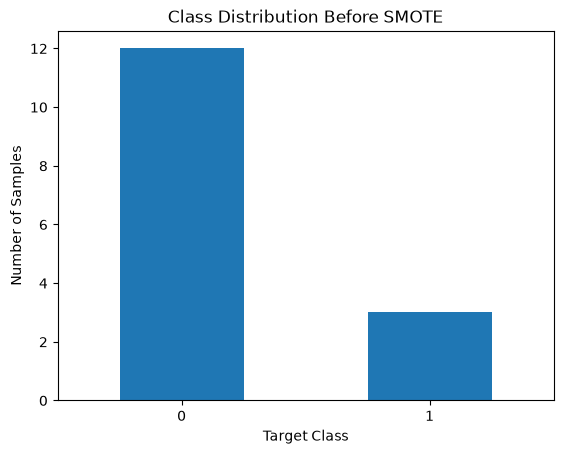

In [3]:
import matplotlib.pyplot as plt

# Visualize class distribution before SMOTE
class_counts.plot(kind="bar")

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [4]:
# Separate features and target

X = data.drop("Target", axis=1)
y = data["Target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (15, 4)
Target shape: (15,)


In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=2)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(y_resampled.value_counts())

print("\nResampled feature shape:", X_resampled.shape)
print("Resampled target shape:", y_resampled.shape)

Before SMOTE:
Target
0    12
1     3
Name: count, dtype: int64

After SMOTE:
Target
0    12
1    12
Name: count, dtype: int64

Resampled feature shape: (24, 4)
Resampled target shape: (24,)


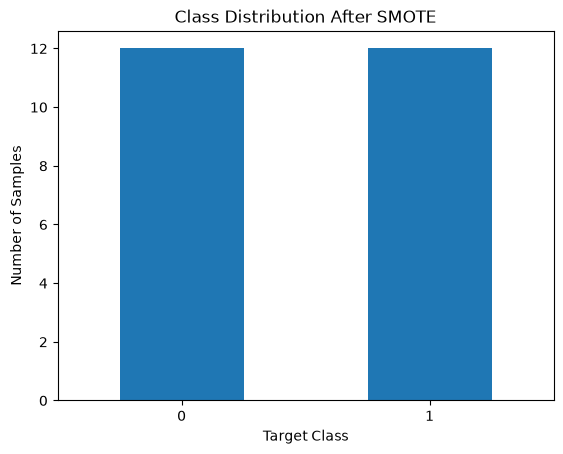

In [10]:
# Visualize class distribution after SMOTE

resampled_counts = y_resampled.value_counts()

resampled_counts.plot(kind="bar")

plt.title("Class Distribution After SMOTE")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [11]:
# Combine resampled features and target

resampled_data = pd.DataFrame(
    X_resampled,
    columns=X.columns
)

resampled_data["Target"] = y_resampled

resampled_data

,Age,Salary,Experience,Score,Target
0,20,25000,1,55,0
1,22,28000,2,58,0
2,25,30000,2,60,0
3,28,35000,3,62,0
4,30,40000,4,65,0
5,32,45000,5,68,0
6,35,50000,6,70,0
7,38,55000,7,72,0
8,40,60000,8,75,0
9,42,65000,9,78,0


## SMOTE Result Analysis

SMOTE increased the minority class from 3 samples to 12 samples.

The final dataset contains:
- Class 0: 12 samples
- Class 1: 12 samples
- Total samples: 24

SMOTE generated 9 synthetic samples for the minority class. These samples are created by interpolating between existing minority-class observations, helping to reduce class imbalance.

### Important Note
SMOTE should be applied only to the training data after splitting the dataset. Applying SMOTE before train-test splitting can cause data leakage and lead to overly optimistic model performance.